<a href="https://colab.research.google.com/github/nnott3/KilterTransformer/blob/main/bert_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Enhanced Transformer for route difficulty prediction with spatial awareness.

# 1. ARCHITECTURE:
#     - Added 2D positional embeddings (pos_x, pos_y)
#     - Added other metadata features: route density, max reach distance
#     - Separate _train_epoch, _validate, _compute_grade_weights
#     - Added model_sumary

# 2. DATA PROCESSING:
#    - Sort holds by y
#   #  - Data augmentation: shuffle of non-start/finish holds during training
#   #  - Hold frequency by grade: Track how often each hold appears in different V-grades
#   #  - Hold co-occurrence patterns: Capture which holds commonly appear together

# 3. TRAINING:
#    - Early stopping
#    - Penalize errors more heavily on easier climbs (inverse grade weighting)


# Init

In [2]:
!git clone https://github.com/nnott3/KilterTransformer.git

Cloning into 'KilterTransformer'...
remote: Enumerating objects: 201, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 201 (delta 13), reused 12 (delta 6), pack-reused 173 (from 1)
Receiving objects: 100% (201/201), 115.29 MiB | 30.88 MiB/s, done.
Resolving deltas: 100% (86/86), done.


In [1]:
%cd KilterTransformer

/content/KilterTransformer


In [2]:
!ls

bert_improved.ipynb  figs	 project_structure  saved_models
bert.ipynb	     gitignore	 pyproject.toml     src
data		     main.ipynb  readme.md	    utils_old
EDA.ipynb	     models	 req		    uv.lock


In [ ]:
"""
Enhanced Transformer for route difficulty prediction with spatial awareness.
"""
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import BertConfig, BertModel, get_linear_schedule_with_warmup
from tqdm import tqdm
from collections import Counter
import datetime
import re

from src.data_processing import DataPreprocessing, HOLD_ID, HOLDCOORDINATES
from src.evaluation import Evaluation


class SpatialKilterBERT(nn.Module):
    """BERT with 2D positional embeddings and metadata integration."""

    def __init__(self, vocab_size, hidden_dim=128, num_layers=4, num_heads=8, dropout=0.1):
        super().__init__()

        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=hidden_dim,
            num_hidden_layers=num_layers,
            num_attention_heads=num_heads,
            intermediate_size=hidden_dim * 4,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout,
            max_position_embeddings=100,
            pad_token_id=0
            )

        self.bert = BertModel(config)

        # 2D positional embeddings
        self.pos_x_embed = nn.Embedding(17, hidden_dim // 2)
        self.pos_y_embed = nn.Embedding(19, hidden_dim // 2)

        # Metadata projection
        self.angle_proj = nn.Linear(1, hidden_dim)
        self.metadata_proj = nn.Linear(2, hidden_dim)

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, pos_x, pos_y, angle, metadata, attention_mask=None):
        bert_out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
            output_attentions=True
        )

        pos_embed = torch.cat([
            self.pos_x_embed(pos_x),
            self.pos_y_embed(pos_y)
        ], dim=-1)

        spatial_hidden = bert_out.last_hidden_state + pos_embed
        cls_token = spatial_hidden[:, 0]

        angle_emb = self.angle_proj(angle)
        meta_emb = self.metadata_proj(metadata)
        combined = torch.cat([cls_token + angle_emb, meta_emb], dim=-1)

        return self.regressor(combined).squeeze(-1), bert_out.attentions


In [ ]:
class BoulderDataset(Dataset):
    """Dataset with spatial features. HuggingFace Datasets."""

    def __init__(self, routes_data, vocab, max_length=25, augment=False):
        self.routes = routes_data
        self.vocab = vocab
        self.max_length = max_length
        self.augment = augment

    def __len__(self):
        return len(self.routes)

    def __getitem__(self, idx):
        row = self.routes[idx]
        frames = row['frames']

        # # Augment: shuffle non-start/finish holds
        # if self.augment and len(holds_sorted) > 2:
        #     start_finish = [h for h in holds_sorted if list(h.values())[0] in [14, 15]]
        #     middle = [h for h in holds_sorted if list(h.values())[0] not in [14, 15]]
        #     np.random.shuffle(middle)
        #     holds_sorted = start_finish + middle

        # sort by position
        tokens, pos_x, pos_y = self._tokenize_with_positions(frames)

        # Metadata features
        coords = np.array(list(zip(pos_x[1:-1], pos_y[1:-1])))  # exclude CLS/SEP
        reaches = np.linalg.norm(np.diff(coords, axis=0), axis=1)
        x_min, y_min = coords.min(axis=0)
        x_max, y_max = coords.max(axis=0)
        width = x_max - x_min
        height = y_max - y_min
        density = len(coords)/(width*height) if (width and height) else 0
        max_reach = max(reaches)


        angle = row['angle_y'] if row['angle_y'] is not None and str(row['angle_y']) != 'nan' else 0.0
        difficulty = row['display_difficulty']

        # Pad sequences
        attention_mask = [1] * len(tokens)
        pad_len = self.max_length - len(tokens)
        tokens.extend([0] * pad_len)
        pos_x.extend([0] * pad_len)
        pos_y.extend([0] * pad_len)
        attention_mask.extend([0] * pad_len)

        return {
            'input_ids': torch.LongTensor(tokens[:self.max_length]),
            'pos_x': torch.LongTensor(pos_x[:self.max_length]),
            'pos_y': torch.LongTensor(pos_y[:self.max_length]),
            'angle': torch.FloatTensor([angle]),
            'metadata': torch.FloatTensor([density, max_reach]),
            'attention_mask': torch.FloatTensor(attention_mask[:self.max_length]),
            'difficulty': torch.FloatTensor([difficulty]),
            'v_grade': row['v_grade']
        }

    def _tokenize_with_positions(self, frames):
        """Convert frames to tokens with 2D positions."""
        tokens = [1]  # [CLS]
        pos_x = [0]
        pos_y = [0]

        frame_split = [f for f in frames.split('_')
                        if ('angle' not in f) and ('grade' not in f)]

        hold_info = []
        for f in frame_split[: (self.max_length - 2)]:
            token = self.vocab.get(f, 0)
            x, y = HOLDCOORDINATES[HOLD_ID.index(int(f[-4:]))]
            hold_info.append((f, token, x, y))

        def sort_logic(item):
            f, token, x, y = item
            if "start" in f:
                order = 0
            elif "finish" in f:
                order = 2
            else:
                order = 1
            return (order, -y)  # sort by order first, then pos_y desc

        hold_info = sorted(hold_info, key=sort_logic)
        for f, token, x, y in hold_info:
            tokens.append(token)
            pos_x.append(int(x * 16 / 1800))  # Scale x to 0-16
            pos_y.append(int(y * 18 / 1200))  # Scale y to 0-18


        tokens.append(2)  # [SEP]
        pos_x.append(0)
        pos_y.append(0)

        return tokens, pos_x, pos_y




In [ ]:
class KilterEncoder:

    def __init__(self, model_name='enhanced_transformer', hidden_dim=128, num_layers=4):
        self.model_name = model_name
        self.max_length = 25
        self.vocab = self._build_vocab()
        self.vocab_size = len(self.vocab)
        self.model = SpatialKilterBERT(len(self.vocab), hidden_dim, num_layers)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.scaler = GradScaler()

    def _build_vocab(self):
        """Build vocabulary with hand_or_foot encoding."""
        vocab = {'[PAD]': 0, '[CLS]': 1, '[SEP]': 2}
        token_id = 3
        for angle in range(20, 60, 5):
            vocab[f"angle{angle}"] = token_id
            token_id += 1

        for hold_id in HOLD_ID:
            for func in ['start', 'hand', 'finish', 'feet']:
                vocab[f"{func}{hold_id}"] = token_id
                token_id += 1
        return vocab


    def train_model(self, train_data, val_data, epochs=30, batch_size=64, lr=2e-4, early_stop=3):
        """Train with mixed precision and early stopping."""

        train_dataset = BoulderDataset(train_data, self.vocab,  augment=True)
        val_dataset = BoulderDataset(val_data, self.vocab, augment=False)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=0.01)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=len(train_loader) * epochs // 10,
            num_training_steps=len(train_loader) * epochs
            )

        grade_weights = self._compute_grade_weights(train_data)

        best_val_loss = float('inf')
        patience_counter = 0

        print(f"Training {self.model_name} ...")

        for epoch in range(epochs):
            train_loss = self._train_epoch(train_loader, optimizer, scheduler, grade_weights, epoch, epochs)
            val_loss = self._validate(val_loader, grade_weights)

            print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                self.save_model()
            else:
                patience_counter += 1
                if patience_counter >= early_stop:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

            if epoch % 10 == 0 and epoch != 0:
                timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
                self.save_model(f"{self.model_name}_{epoch}_{timestamp}.pt")

    def _train_epoch(self, loader, optimizer, scheduler, grade_weights, epoch, total_epochs):
        """Single training epoch with mixed precision."""
        self.model.train()
        total_loss = 0

        for batch in tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False):
            v_grades = batch.pop('v_grade')
            batch = {k: v.to(self.device) for k, v in batch.items()}

            optimizer.zero_grad()

            with autocast():
                pred, _ = self.model(
                    batch['input_ids'], batch['pos_x'], batch['pos_y'],
                    batch['angle'], batch['metadata'], batch['attention_mask']
                )

                weights = torch.tensor([grade_weights.get(g, 1.0) for g in v_grades],
                                      device=self.device)
                loss = (nn.SmoothL1Loss(reduction='none')(pred, batch['difficulty'].squeeze()) * weights).mean()

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.scaler.step(optimizer)
            self.scaler.update()
            scheduler.step()

            total_loss += loss.item()

        return total_loss / len(loader)

    def _validate(self, loader, grade_weights):
        """Validation with weighted loss."""
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch in loader:
                v_grades = batch.pop('v_grade')
                batch = {k: v.to(self.device) for k, v in batch.items()}

                pred, _ = self.model(
                    batch['input_ids'], batch['pos_x'], batch['pos_y'],
                    batch['angle'], batch['metadata'], batch['attention_mask']
                )

                weights = torch.tensor([grade_weights.get(g, 1.0) for g in v_grades],
                                      device=self.device)
                loss = (nn.SmoothL1Loss(reduction='none')(pred, batch['difficulty'].squeeze()) * weights).mean()
                total_loss += loss.item()

        return total_loss / len(loader)

    def _compute_grade_weights(self, data):
        """Compute weights to penalize errors on easier grades more."""
        # Convert to list for counting
        grades_list = [row['v_grade'] for row in data]
        grade_counts = Counter(grades_list)

        def grade_to_num(grade_str):
            match = re.search(r'\d+', str(grade_str))
            return int(match.group()) if match else 0

        max_grade_num = max(grade_to_num(g) for g in grade_counts.keys())

        weights = {grade: (max_grade_num - grade_to_num(grade) + 1) / max_grade_num
                  for grade in grade_counts.keys()}
        return weights

    def predict(self, routes_data, batch_size=64):
        """Predict with attention extraction."""
        dataset = BoulderDataset(routes_data, self.vocab, augment=False)
        loader = DataLoader(dataset, batch_size=batch_size)

        self.model.eval()
        predictions = []
        attentions = []

        with torch.no_grad():
            for batch in loader:
                batch.pop('v_grade')
                batch = {k: v.to(self.device) for k, v in batch.items()}

                pred, attn = self.model(
                    batch['input_ids'], batch['pos_x'], batch['pos_y'],
                    batch['angle'], batch['metadata'], batch['attention_mask']
                )

                predictions.extend(pred.cpu().numpy())
                if attn:
                    attentions.append(attn[-1].cpu().numpy())

        return np.array(predictions), attentions

    def save_model(self, name=None):
        if name is None:
            name = f'{self.model_name}.pt'
        torch.save({
            'model_state': self.model.state_dict(),
            'vocab': self.vocab,
        }, f'saved_models/{name}')

    def load_model(self, path=None):
        if path is None:
            path = f'{self.model_name}.pt'
        checkpoint = torch.load(f'saved_models/{path}', map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state'])
        self.vocab = checkpoint['vocab']
        self.model.eval()

    def model_summary(self):
        """Print model architecture and parameters."""
        print(f"\n{'='*60}")
        print(f"Model: {self.model_name}")
        print(f"{'='*60}")
        print(f"Vocabulary size: {len(self.vocab)}")
        print(f"Max sequence length: {self.max_length}")

        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)

        print(f"\nTotal parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
        print(f"Model size: {total_params * 4 / 1024**2:.2f} MB")

        print(f"\nArchitecture:")
        for name, module in self.model.named_children():
            params = sum(p.numel() for p in module.parameters())
            print(f"  {name}: {params:,} parameters")
        print(f"{'='*60}\n")

In [ ]:
from datasets import ClassLabel, disable_progress_bars

disable_progress_bars()

dp = DataPreprocessing()
climbs = dp.load_climbs()
print(f"Dataset: {len(climbs)} climbs")

num_classes = len(set(climbs["v_grade"]))
climbs = climbs.cast_column("v_grade", ClassLabel(num_classes=num_classes))

# Split train/test
climbs = climbs.train_test_split(test_size=0.1, seed=42, stratify_by_column="v_grade")
test_df = climbs['test']

# Split train/val
train_val = climbs['train'].train_test_split(test_size=0.15, seed=42, stratify_by_column="v_grade")
train_df = train_val['train']
val_df = train_val['test']

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

model_name = 'improved_bert_v0'
encoder = KilterEncoder(model_name=model_name, hidden_dim=256, num_layers=4)
print(f"Vocabulary size: {encoder.vocab_size}")
print(f"Model parameters: {sum(p.numel() for p in encoder.model.parameters()):,}")
print(f"{encoder.model_summary()}")
print(f"Device: {encoder.device}")

encoder.train_model(train_df, val_df, epochs=40, batch_size=64, lr=2e-4)



Loaded 76992 routes from cache data/climbs_cleaned.csv
Dataset: 76992 climbs
Train: 58898, Val: 10394, Test: 7700
Vocabulary size: 1915
Model parameters: 3,879,681

Model: improved_bert_v0
Vocabulary size: 1915
Max sequence length: 25

Total parameters: 3,879,681
Trainable parameters: 3,879,681
Model size: 14.80 MB

Architecture:
  bert: 3,741,696 parameters
  pos_x_embed: 2,176 parameters
  pos_y_embed: 2,432 parameters
  angle_proj: 512 parameters
  metadata_proj: 768 parameters
  regressor: 132,097 parameters

None
Device: cuda


/tmp/ipython-input-4091572046.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler()


Training improved_bert_v0 ...


Epoch 1/40:   0%|          | 0/921 [00:00<?, ?it/s]/tmp/ipython-input-4091572046.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40 | Train: 15.4266 | Val: 12.4093 | LR: 5.00e-05


...

Epoch 16/40 | Train: 0.7768 | Val: 0.8329 | LR: 1.33e-04


Epoch 17/40 | Train: 0.7494 | Val: 0.8325 | LR: 1.28e-04


Epoch 18/40 | Train: 0.7309 | Val: 0.8370 | LR: 1.22e-04


Epoch 19/40 | Train: 0.7136 | Val: 0.8630 | LR: 1.17e-04


Epoch 20/40 | Train: 0.7023 | Val: 0.8623 | LR: 1.11e-04
Early stopping at epoch 20



Evaluating on test set...

improved_bert_v0 Performance:
  R²:   0.8059
  MAE:  1.2384
  RMSE: 1.6329
  Within ±1 V-grade: 83.84%


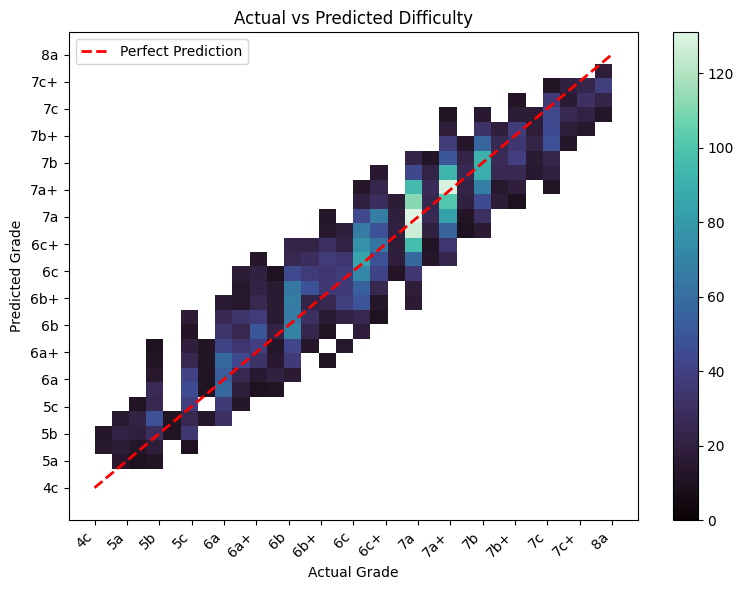

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
from src.data_processing import DataPreprocessing
from src.evaluation import Evaluation


# Load best model
encoder.load_model('improved_bert_v0.pt')

# Evaluate
print("\nEvaluating on test set...")
y_test = np.array(test_df['display_difficulty'])
y_pred, attention = encoder.predict(test_df)

evaluator = Evaluation()
scores = evaluator.get_scores(y_test, y_pred, "improved_bert_v0")

evaluator.plot_predictions(y_test, y_pred)

In [13]:
from getpass import getpass
token = getpass("Enter your GitHub token: ")

!git config --global user.email "treepatchantaurai@gmail.com"
!git config --global user.name "nnott3"
!git remote set-url origin https://{token}@github.com/nnott3/KilterTransformer.git



Enter your GitHub token: ··········


In [ ]:
!git add saved_models/improved_bert_v1.pt
!git add saved_models/improved_bert_v1_10_20251030-124806.pt
!git add saved_models/improved_bert_v1_10_20251030-131117.pt

In [ ]:
!git commit -m "improved_bert_v1 (256 dim) (83.8%)"

[main 1c0779b] improved_bert_v1 (256 dim) (83.8%)
 3 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 saved_models/improved_bert_v1.pt
 create mode 100644 saved_models/improved_bert_v1_10_20251030-124806.pt
 create mode 100644 saved_models/improved_bert_v1_10_20251030-131117.pt


# Accuracy Record
- Basic BERT (83%)
- 1st Add-on (79.8%)
  - 2D positional embeddings
  - Features (Density + Max_reach)
  - Early stopping = 5
  - weights to penalize errors on easier grades more
- 2nd (78.5%)
  - hold freq, co-occurence
- 3rd (85%)
  - ensemble xgb + bert (bert didnt even try)
  - 100% weight on xgb
- 4rd (85%)
  - basic xgb with bert embeddings as features
  

# Ensemble w/ XGB

In [13]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from torch.utils.data import DataLoader
from datasets import ClassLabel, disable_progress_bars

class HybridEnsemble:
    """BERT + XGBoost ensemble."""

    def __init__(self, bert_hidden_dim=128):
        self.bert = KilterEncoder(model_name='bert_hybrid', hidden_dim=bert_hidden_dim, num_layers=4)
        self.xgb = xgb.XGBRegressor(
            n_estimators=500, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            tree_method='hist', early_stopping_rounds=20
        )
        self.bert_weight = 0.6
        self.xgb_weight = 0.4

    def extract_features(self, dataset):
        """Extract handcrafted features from routes."""
        features = []

        for row in dataset:
            frames = row['frames']
            holds = [f for f in frames.split('_') if 'angle' not in f and 'grade' not in f]

            # Counts
            num_holds = len(holds)
            num_hands = sum(1 for f in holds if 'hand' in f)
            num_feet = sum(1 for f in holds if 'feet' in f)

            # Positions
            positions = np.array([HOLDCOORDINATES[HOLD_ID.index(int(f[-4:]))] for f in holds])

            if len(positions) > 1:
                # Spatial
                width = np.ptp(positions[:, 0])
                height = np.ptp(positions[:, 1])
                area = width * height if width > 0 and height > 0 else 1
                density = num_holds / area

                # Movement
                distances = np.linalg.norm(np.diff(positions, axis=0), axis=1)
                avg_dist = distances.mean()
                max_dist = distances.max()
                std_dist = distances.std()
            else:
                width = height = area = density = 0
                avg_dist = max_dist = std_dist = 0

            angle = row['angle_y'] if row['angle_y'] is not None else 0.0
            hand_feet_ratio = num_hands / num_feet if num_feet > 0 else num_hands

            features.append([
                num_holds, num_hands, num_feet, hand_feet_ratio,
                width, height, area, density,
                avg_dist, max_dist, std_dist, angle
            ])

        return np.array(features)

    def get_bert_embeddings(self, dataset):
        """Extract BERT CLS embeddings."""
        bert_dataset = BoulderDataset(dataset, self.bert.vocab, self.bert.max_length)
        loader = DataLoader(bert_dataset, batch_size=64, shuffle=False)

        self.bert.model.eval()
        embeddings = []

        with torch.no_grad():
            for batch in loader:
                input_ids = batch['input_ids'].to(self.bert.device)
                mask = batch['attention_mask'].to(self.bert.device)

                outputs = self.bert.model.bert(input_ids=input_ids, attention_mask=mask, return_dict=True)
                embeddings.append(outputs.last_hidden_state[:, 0].cpu().numpy())

        return np.vstack(embeddings)

    def train(self, train_ds, val_ds, bert_model_path='bert_128.pt', train_bert=False, epochs=30):
        """Train hybrid ensemble. Load pre-trained BERT by default."""
        # Load or train BERT
        if train_bert:
            print("Training BERT from scratch...")
            self.bert.train_model(train_ds, val_ds, epochs=epochs, batch_size=64)
        else:
            print(f"Loading pre-trained BERT: {bert_model_path}")
            self.bert.load_model(bert_model_path)

        # Prepare XGBoost data
        print("Extracting features for XGBoost...")
        X_train = np.hstack([self.extract_features(train_ds), self.get_bert_embeddings(train_ds)])
        X_val = np.hstack([self.extract_features(val_ds), self.get_bert_embeddings(val_ds)])
        y_train = np.array([row['display_difficulty'] for row in train_ds])
        y_val = np.array([row['display_difficulty'] for row in val_ds])

        print(f"Feature shape: {X_train.shape} (handcrafted: 12, BERT embeddings: {X_train.shape[1]-12})")

        # Train XGBoost
        print("Training XGBoost...")
        self.xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

        # Tune ensemble weights
        print("\nTuning ensemble weights on validation set...")
        bert_pred = self.bert.predict(val_ds)
        xgb_pred = self.xgb.predict(X_val)

        best_mae = float('inf')
        for w in np.arange(0, 1.05, 0.05):
            mae = mean_absolute_error(y_val, w * bert_pred + (1-w) * xgb_pred)
            if mae < best_mae:
                best_mae = mae
                self.bert_weight = w

        self.xgb_weight = 1 - self.bert_weight
        print(f"\nOptimal weights: BERT={self.bert_weight:.2f}, XGBoost={self.xgb_weight:.2f}")
        print(f"Validation MAE: {best_mae:.4f}")

        # Save XGBoost
        self.xgb.save_model('saved_models/xgb_hybrid.json')
        print("XGBoost model saved!")

    def predict(self, test_ds):
        """Predict with weighted ensemble."""
        print("Making predictions...")
        bert_pred = self.bert.predict(test_ds)

        X_test = np.hstack([self.extract_features(test_ds), self.get_bert_embeddings(test_ds)])
        xgb_pred = self.xgb.predict(X_test)

        return self.bert_weight * bert_pred + self.xgb_weight * xgb_pred

    def load_models(self, bert_path='bert_hybrid.pt', xgb_path='saved_models/xgb_hybrid.json'):
        """Load both pre-trained models for inference."""
        print(f"Loading BERT: {bert_path}")
        self.bert.load_model(bert_path)
        print(f"Loading XGBoost: {xgb_path}")
        self.xgb.load_model(xgb_path)


Loaded 76992 routes from cache data/climbs_cleaned.csv
Dataset: 76992 climbs
Train: 58898, Val: 10394, Test: 7700
Loading pre-trained BERT: bert_hybrid.pt
Extracting features for XGBoost...
Feature shape: (58898, 140) (handcrafted: 12, BERT embeddings: 128)
Training XGBoost...
[0]	validation_0-rmse:3.56087
[50]	validation_0-rmse:1.64538
[100]	validation_0-rmse:1.62005
[150]	validation_0-rmse:1.60920
[200]	validation_0-rmse:1.59989
[250]	validation_0-rmse:1.59189
[300]	validation_0-rmse:1.58484
[350]	validation_0-rmse:1.57917
[400]	validation_0-rmse:1.57361
[450]	validation_0-rmse:1.56998
[499]	validation_0-rmse:1.56677

Tuning ensemble weights on validation set...

Optimal weights: BERT=0.00, XGBoost=1.00
Validation MAE: 1.1871
XGBoost model saved!

Evaluating on test set...
Making predictions...

BERT+XGBoost Hybrid Performance:
  R²:   0.8222
  MAE:  1.1749
  RMSE: 1.5628
  Within ±1 V-grade: 85.27%


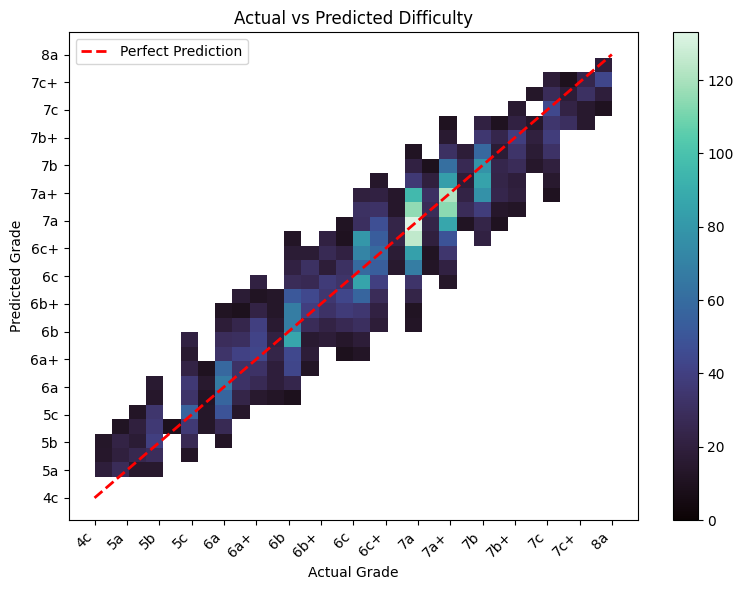

In [14]:
disable_progress_bars()

# Load data
dp = DataPreprocessing()
climbs = dp.load_climbs()
print(f"Dataset: {len(climbs)} climbs")

num_classes = len(set(climbs["v_grade"]))
climbs = climbs.cast_column("v_grade", ClassLabel(num_classes=num_classes))

# Split data
climbs = climbs.train_test_split(test_size=0.1, seed=42, stratify_by_column="v_grade")
train_val = climbs['train'].train_test_split(test_size=0.15, seed=42, stratify_by_column="v_grade")

train_ds = train_val['train']
val_ds = train_val['test']
test_ds = climbs['test']
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

# Train hybrid (using pre-trained BERT)
hybrid = HybridEnsemble(bert_hidden_dim=128)
hybrid.train(
    train_ds, val_ds,
    bert_model_path='bert_hybrid.pt',
    train_bert=False  # Don't retrain BERT
)

# Evaluate
print("\nEvaluating on test set...")
y_test = np.array(test_ds['display_difficulty'])
y_pred = hybrid.predict(test_ds)

evaluator = Evaluation()
evaluator.get_scores(y_test, y_pred, "BERT+XGBoost Hybrid")
evaluator.plot_predictions(y_test, y_pred)

In [15]:
from getpass import getpass
token = getpass("Enter your GitHub token: ")

!git config --global user.email "treepatchantaurai@gmail.com"
!git config --global user.name "nnott3"
!git remote set-url origin https://{token}@github.com/nnott3/KilterTransformer.git

Enter your GitHub token: ··········


In [16]:
!git add saved_models/bert_hybrid.pt
!git add saved_models/xgb_hybrid.json

In [17]:
!git commit -m "ensenble xgb + bert (85.3%)"
!git push origin main

[main 83324b8] ensenble xgb + bert (85.3%)
 2 files changed, 1 insertion(+)
 create mode 100644 saved_models/bert_hybrid.pt
 create mode 100644 saved_models/xgb_hybrid.json
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 6.40 MiB | 6.12 MiB/s, done.
Total 5 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/nnott3/KilterTransformer.git
   a39f1b8..83324b8  main -> main


# XGB with BERT embeddings

In [3]:
"""
Transformer-based encoder using HuggingFace for route difficulty prediction.
"""
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from typing import Dict
from tqdm import tqdm
from transformers import BertConfig, BertModel, get_linear_schedule_with_warmup
import datetime
from src.data_processing import DataPreprocessing, HOLD_ID, HOLDCOORDINATES
from src.evaluation import Evaluation


class KilterBERT(nn.Module):
    """BERT model with custom regression head for difficulty prediction."""

    def __init__(self, vocab_size, hidden_dim=128, num_layers=4, num_heads=8, dropout=0.1):
        super().__init__()

        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=hidden_dim,
            num_hidden_layers=num_layers,
            num_attention_heads=num_heads,
            intermediate_size=hidden_dim * 4,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout,
            max_position_embeddings=100,
            pad_token_id=0
        )

        self.bert = BertModel(config)
        self.angle_proj = nn.Linear(1, hidden_dim)

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, angle, attention_mask=None):
        # Get BERT embeddings
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )


        # Get [CLS] token representation
        cls_embedding = outputs.last_hidden_state[:, 0]

        angle_emb = self.angle_proj(angle)
        combined = cls_embedding + angle_emb

        return self.regressor(combined).squeeze(-1)


class BoulderDataset(Dataset):
    """PyTorch dataset for boulder routes."""

    def __init__(self, routes_df: pd.DataFrame, vocab: Dict, max_length: int = 25):
        self.routes = routes_df #.reset_index(drop=True)
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.routes)

    def __getitem__(self, idx):
        row = self.routes[idx]
        tokens = self._tokenize(row['frames'])

        # Handle angle (works for both None and NaN)
        angle = row['angle_y'] if row['angle_y'] is not None and str(row['angle_y']) != 'nan' else 0.0
        difficulty = row['display_difficulty']

        # Pad tokens
        attention_mask = [1] * len(tokens)
        while len(tokens) < self.max_length:
            tokens.append(0)  # [PAD]
            attention_mask.append(0)

        return {
            'input_ids': torch.LongTensor(tokens[:self.max_length]),
            'angle': torch.FloatTensor([angle]),
            'attention_mask': torch.FloatTensor(attention_mask[:self.max_length]),
            'difficulty': torch.FloatTensor([difficulty])
        }


    def _tokenize(self, frames):
        """Convert holds to frame sequence: [CLS] hold_tokens... [SEP].
        e.g. angle40_grade23_start1109_start1125_hand1163 """

        tokens = [1] # [CLS]
        frame_split = [f for f in frames.split('_') if ('grade' not in f) and ('angle' not in f)]
        for hold in frame_split[:(self.max_length - 2)]:
            token = self.vocab.get(hold, 0)
            tokens.append(token)

        tokens.append(2) # [SEP]
        return tokens


class KilterEncoder:
    """HuggingFace BERT-based encoder"""

    def __init__(self, model_name='transformer', vocab_size=None, hidden_dim=128, num_layers=4, max_length=25):
        self.model_name = model_name
        self.max_length = max_length
        self.vocab = self._build_vocab()
        self.vocab_size = vocab_size or len(self.vocab)
        self.model = KilterBERT(self.vocab_size, hidden_dim, num_layers)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)

    def _build_vocab(self) -> Dict[str, int]:
        """Build vocabulary: hold_id_func → token_id."""
        vocab = {'[PAD]': 0, '[CLS]': 1, '[SEP]': 2}
        token_id = 3
        for angle in range(20, 60, 5):
            vocab[f"angle{angle}"] = token_id
            token_id += 1

        for hold_id in HOLD_ID:
            for func in ['start', 'hand', 'finish', 'feet']:
                vocab[f"{func}{hold_id}"] = token_id
                token_id += 1
        return vocab

    def train_model(self, train_data, val_data=None,
                   epochs: int = 30, batch_size: int = 64, lr: float = 2e-4):
        """Train the transformer model."""
        train_dataset = BoulderDataset(train_data, self.vocab, self.max_length)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        if val_data is not None:
            val_dataset = BoulderDataset(val_data, self.vocab, self.max_length)
            val_loader = DataLoader(val_dataset, batch_size=batch_size)

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=0.01)
        total_steps = len(train_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=total_steps // 10,
            num_training_steps=total_steps
        )
        criterion = nn.SmoothL1Loss()

        best_val_loss = float('inf')

        print(f"Training {self.model_name} ...")
        for epoch in range(epochs):
            # Training
            self.model.train()
            train_loss = 0
            for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
                input_ids = batch['input_ids'].to(self.device)
                angle = batch['angle'].to(self.device)
                mask = batch['attention_mask'].to(self.device)
                difficulty = batch['difficulty'].squeeze().to(self.device)

                optimizer.zero_grad()
                pred = self.model(input_ids, angle, mask)
                loss = criterion(pred, difficulty)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

                train_loss += loss.item()

            train_loss /= len(train_loader)

            # Validation
            if val_data is not None:
                self.model.eval()
                val_loss = 0
                with torch.no_grad():
                    for batch in val_loader:
                        input_ids = batch['input_ids'].to(self.device)
                        angle = batch['angle'].to(self.device)
                        mask = batch['attention_mask'].to(self.device)
                        difficulty = batch['difficulty'].squeeze().to(self.device)

                        pred = self.model(input_ids, angle, mask)
                        loss = criterion(pred, difficulty)
                        val_loss += loss.item()

                val_loss /= len(val_loader)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    self.save_model()
                if epoch % 10 == 0 and epoch != 0:
                    timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
                    self.save_model(f"{self.model_name}_{epoch}_{timestamp}.pt")

                print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, LR={scheduler.get_last_lr()[0]:.2e}")
            else:
                print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}")

    def predict(self, routes_data, batch_size: int = 64) -> np.ndarray:
        """Predict difficulties for routes."""
        dataset = BoulderDataset(routes_data, self.vocab, self.max_length)
        loader = DataLoader(dataset, batch_size=batch_size)

        self.model.eval()
        predictions = []

        with torch.no_grad():
            for batch in loader:
                input_ids = batch['input_ids'].to(self.device)
                angle = batch['angle'].to(self.device)
                mask = batch['attention_mask'].to(self.device)

                pred = self.model(input_ids, angle, mask)
                predictions.extend(pred.cpu().numpy().tolist())

        return np.array(predictions)

    def save_model(self, name: str = None):
        """Save model weights."""
        if name is None:
            name = f'{self.model_name}.pt'
        torch.save(self.model.state_dict(), f'saved_models/{name}')

    def load_model(self, path: str = None):
        """Load model weights."""
        if path is None:
            path = f'{self.model_name}.pt'
        self.model.load_state_dict(torch.load(f'saved_models/{path}', map_location=self.device))
        self.model.eval()

In [9]:
import numpy as np
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from typing import Dict
from transformers import BertConfig, BertModel
from datasets import ClassLabel, disable_progress_bars

from src.data_processing import DataPreprocessing, HOLD_ID, HOLDCOORDINATES
from src.evaluation import Evaluation


class XGBoostBERT:
    """XGBoost using BERT embeddings + pre-computed dataset features."""

    DATASET_FEATURES = [
        'angle_y', 'quality_average', 'ascensionist_count',
        'num_holds', 'num_hand', 'num_footonly', 'hand_foot_ratio',
        'avg_reach', 'max_reach', 'route_area', 'hold_density',
        'popularity_score', 'angle_x_holds', 'density_x_angle'
    ]

    def __init__(self, bert_hidden_dim=128):
        self.bert = KilterEncoder(model_name='xgb_bert', hidden_dim=bert_hidden_dim, num_layers=4)
        self.xgb = xgb.XGBRegressor(
            n_estimators=500, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            tree_method='hist', early_stopping_rounds=20
        )

    def extract_dataset_features(self, dataset):
        """Extract pre-computed features from dataset."""
        features = []
        for row in dataset:
            feature_vector = []
            for feat_name in self.DATASET_FEATURES:
                value = row.get(feat_name, 0)
                if value is None or (isinstance(value, float) and np.isnan(value)):
                    value = 0.0
                feature_vector.append(float(value))
            features.append(feature_vector)
        return np.array(features, dtype=np.float32)

    def get_bert_embeddings(self, dataset):
        """Extract BERT CLS embeddings."""
        bert_dataset = BoulderDataset(dataset, self.bert.vocab, self.bert.max_length)
        loader = DataLoader(bert_dataset, batch_size=64, shuffle=False)

        self.bert.model.eval()
        embeddings = []

        with torch.no_grad():
            for batch in loader:
                input_ids = batch['input_ids'].to(self.bert.device)
                mask = batch['attention_mask'].to(self.bert.device)
                outputs = self.bert.model.bert(input_ids=input_ids, attention_mask=mask, return_dict=True)
                embeddings.append(outputs.last_hidden_state[:, 0].cpu().numpy())

        return np.vstack(embeddings).astype(np.float32)

    def train(self, train_ds, val_ds, bert_model_path='bert_hybrid.pt'):
        """Train XGBoost using pre-trained BERT + dataset features."""
        self.bert.load_model(bert_model_path)

        train_feat = self.extract_dataset_features(train_ds)
        val_feat = self.extract_dataset_features(val_ds)
        train_emb = self.get_bert_embeddings(train_ds)
        val_emb = self.get_bert_embeddings(val_ds)

        X_train = np.hstack([train_feat, train_emb])
        X_val = np.hstack([val_feat, val_emb])
        y_train = np.array([row['display_difficulty'] for row in train_ds], dtype=np.float32)
        y_val = np.array([row['display_difficulty'] for row in val_ds], dtype=np.float32)

        self.xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
        self.xgb.save_model('saved_models/xgb_bert_dataset_features.json')

    def predict(self, test_ds):
        """Predict using XGBoost."""
        test_feat = self.extract_dataset_features(test_ds)
        test_emb = self.get_bert_embeddings(test_ds)
        X_test = np.hstack([test_feat, test_emb])
        return self.xgb.predict(X_test)

    def load_model(self, bert_path='bert_hybrid.pt', xgb_path='saved_models/xgb_bert_dataset_features.json'):
        """Load pre-trained models."""
        self.bert.load_model(bert_path)
        self.xgb.load_model(xgb_path)

    def analyze_feature_importance(self, output_path='feature_importance.png'):
        """Plot feature importance."""
        import matplotlib.pyplot as plt

        importance = self.xgb.feature_importances_
        n_bert_dims = len(importance) - len(self.DATASET_FEATURES)
        feature_names = self.DATASET_FEATURES + [f'bert_{i}' for i in range(n_bert_dims)]

        top_indices = np.argsort(importance)[-20:]
        top_importance = importance[top_indices]
        top_names = [feature_names[i] for i in top_indices]

        plt.figure(figsize=(10, 8))
        plt.barh(range(len(top_names)), top_importance)
        plt.yticks(range(len(top_names)), top_names)
        plt.xlabel('Importance')
        plt.title('Top 20 Most Important Features')
        plt.tight_layout()




Loaded 76992 routes from cache data/climbs_cleaned.csv
[0]	validation_0-rmse:3.56622
[50]	validation_0-rmse:1.63796
[100]	validation_0-rmse:1.61336
[150]	validation_0-rmse:1.60416
[200]	validation_0-rmse:1.59440
[250]	validation_0-rmse:1.58769
[300]	validation_0-rmse:1.58116
[350]	validation_0-rmse:1.57556
[400]	validation_0-rmse:1.57069
[450]	validation_0-rmse:1.56673
[499]	validation_0-rmse:1.56223

XGBoost + BERT + Dataset Features Performance:
  R²:   0.8237
  MAE:  1.1686
  RMSE: 1.5562
  Within ±1 V-grade: 85.47%


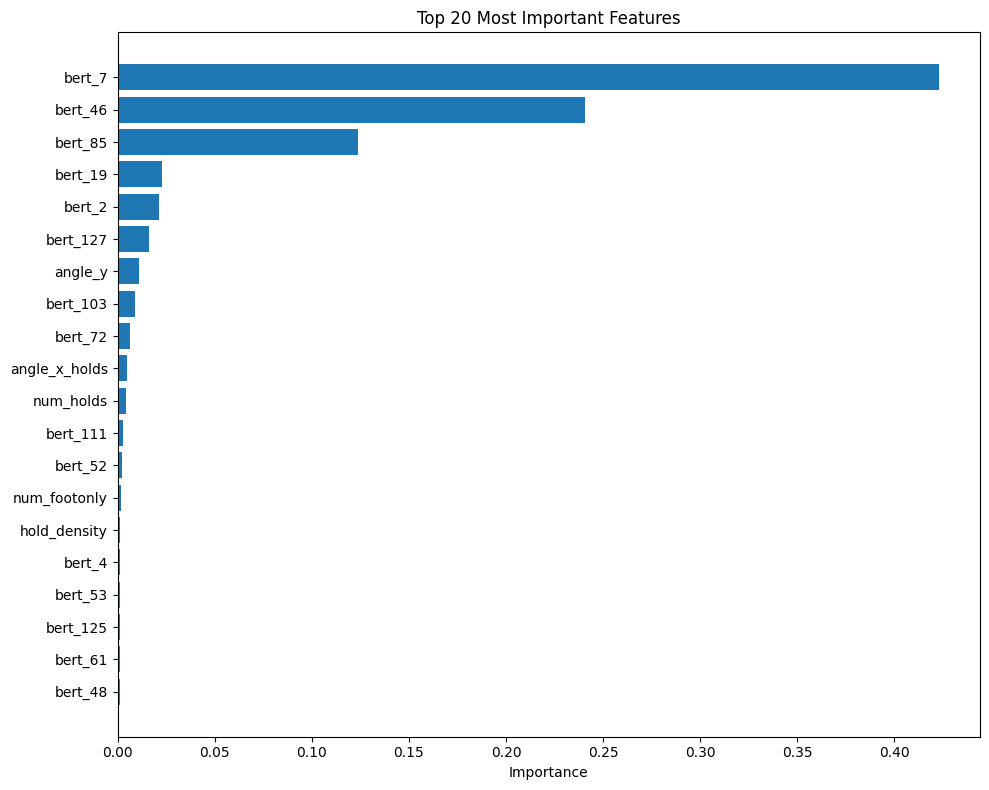

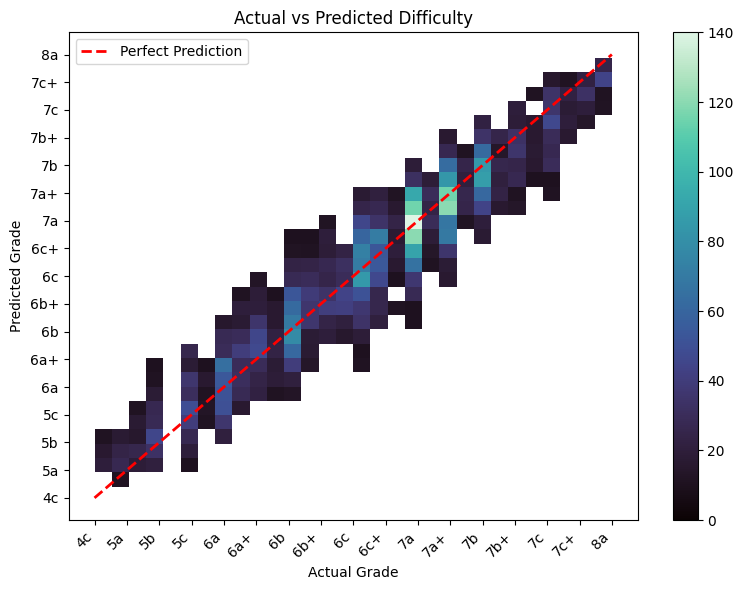

In [10]:
disable_progress_bars()

dp = DataPreprocessing()
climbs = dp.load_climbs()

climbs = climbs.cast_column("v_grade", ClassLabel(num_classes=len(set(climbs["v_grade"]))))
climbs = climbs.train_test_split(test_size=0.1, seed=42, stratify_by_column="v_grade")
train_val = climbs['train'].train_test_split(test_size=0.15, seed=42, stratify_by_column="v_grade")

train_ds, val_ds, test_ds = train_val['train'], train_val['test'], climbs['test']

# Train
model = XGBoostBERT(bert_hidden_dim=128)
model.train(train_ds, val_ds, bert_model_path='bert_hybrid.pt')

# Analyze
model.analyze_feature_importance()

# Evaluate
y_test = np.array(test_ds['display_difficulty'])
y_pred = model.predict(test_ds)

evaluator = Evaluation()
evaluator.get_scores(y_test, y_pred, "XGBoost + BERT + Dataset Features")
evaluator.plot_predictions(y_test, y_pred)

In [14]:
!git add saved_models/xgb_bert_dataset_features.json
!git commit -m "xgb with bert embeddings"
!git push origin main

[main e0d0da8] xgb with bert embeddings
 1 file changed, 1 insertion(+)
 create mode 100644 saved_models/xgb_bert_dataset_features.json
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 2.60 MiB | 3.73 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/nnott3/KilterTransformer.git
   c9ffe60..e0d0da8  main -> main


# Embeddings

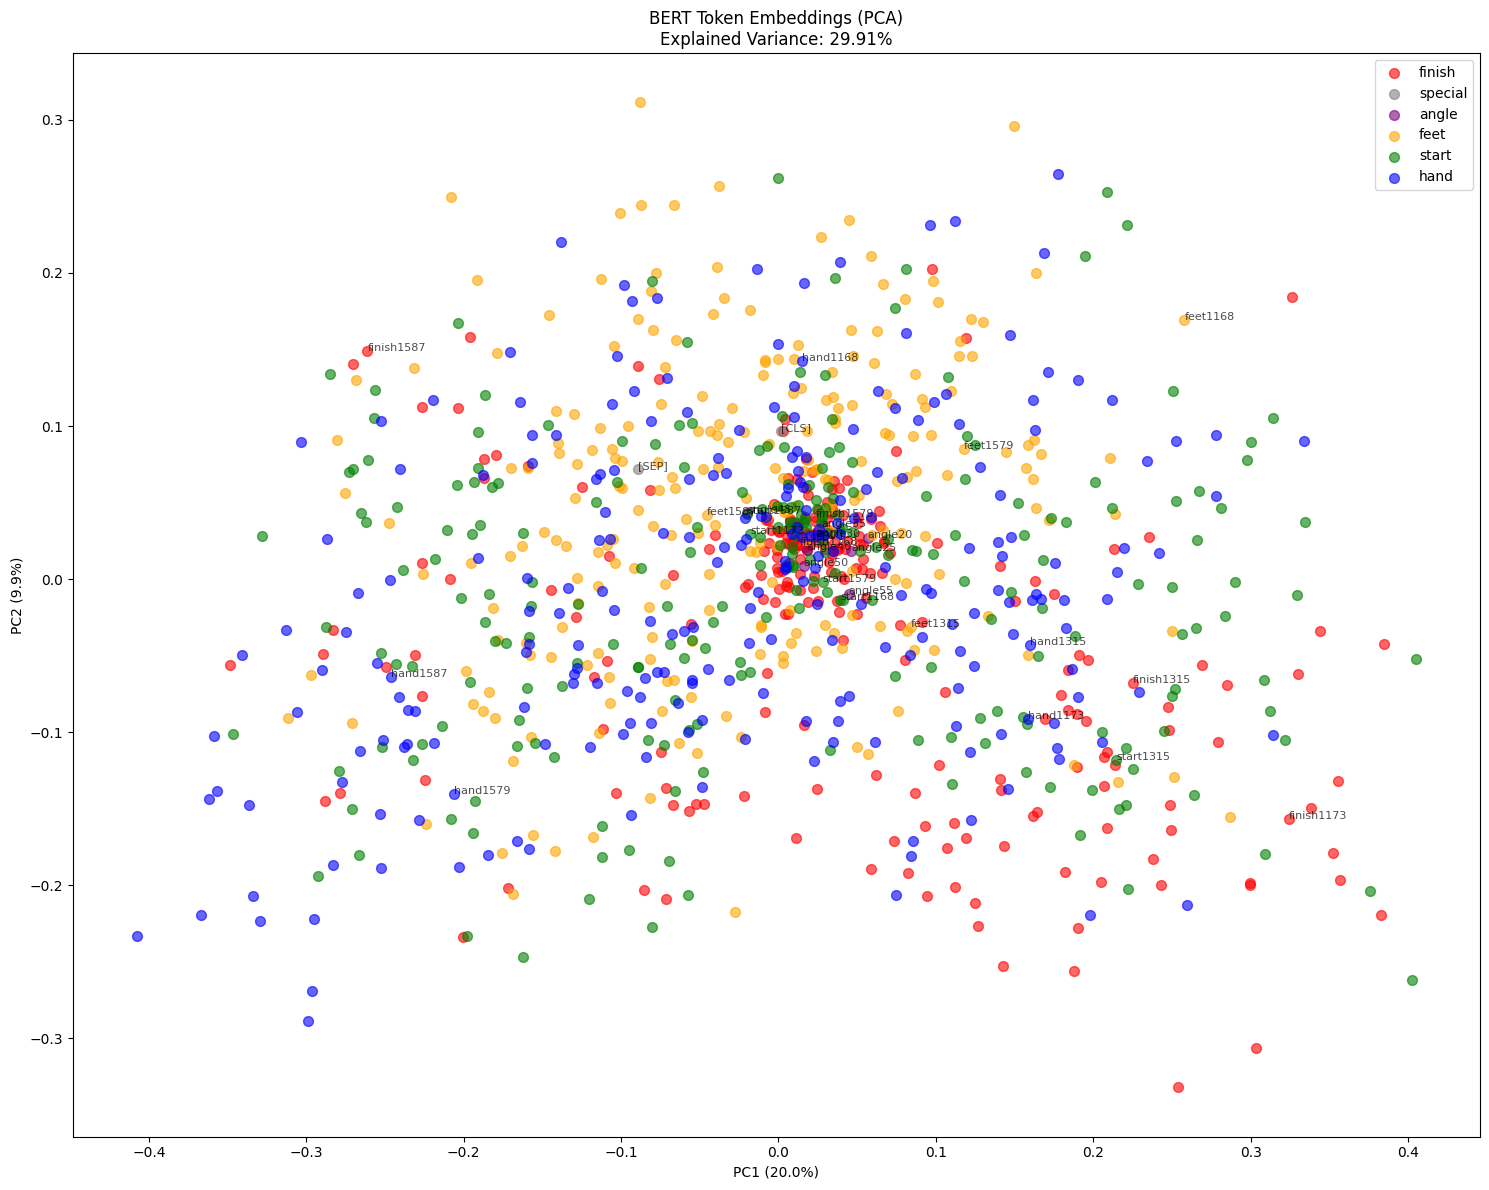

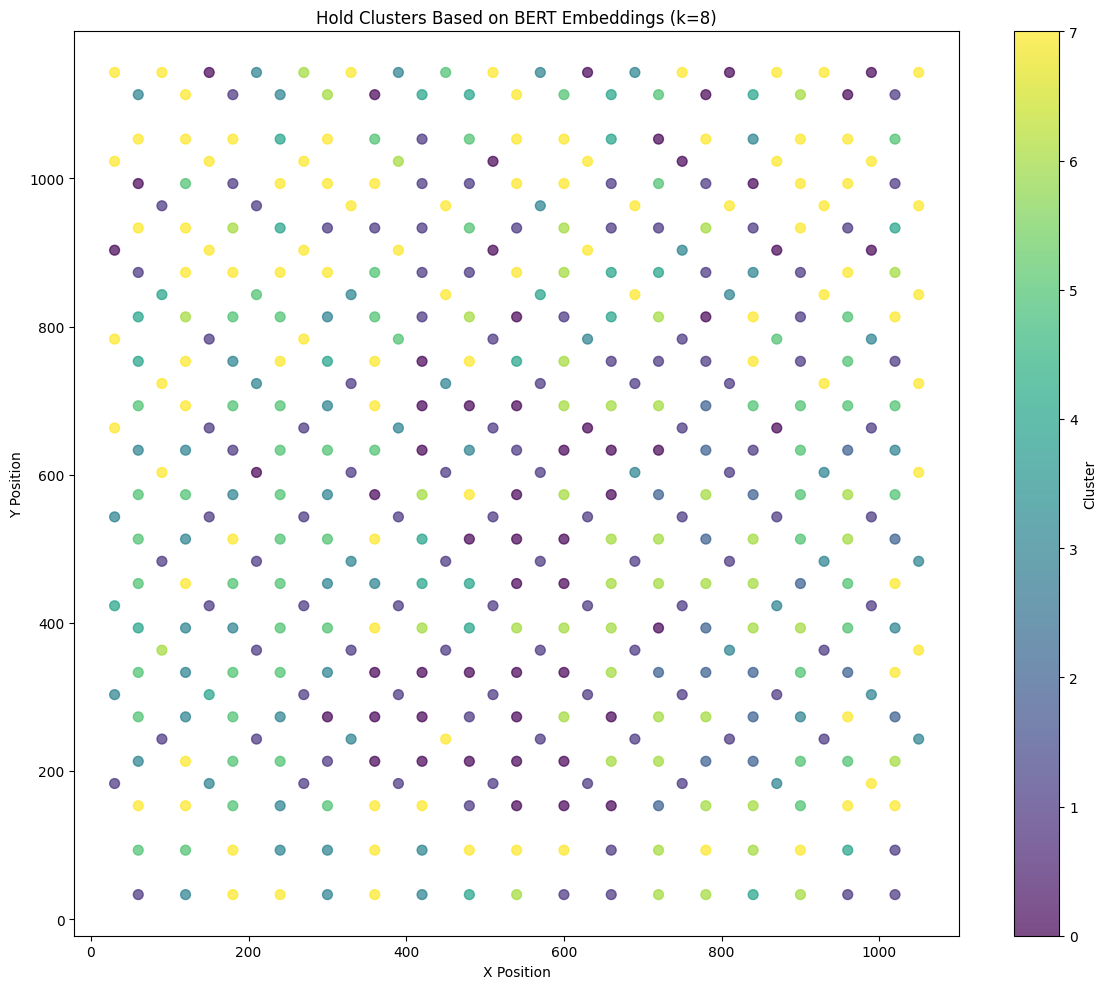

In [20]:
def visualize_bert_embeddings_pca(bert_model, n_samples=200, figsize=(15, 12)):
    """
    Visualize BERT token embeddings using PCA.

    Args:
        bert_model: Trained KilterEncoder instance
        n_samples: Number of tokens to visualize
        figsize: Figure size
    """
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA

    # Extract embeddings
    embedding_layer = bert_model.model.bert.embeddings.word_embeddings
    embeddings = embedding_layer.weight.detach().cpu().numpy()
    vocab = bert_model.vocab
    inv_vocab = {v: k for k, v in vocab.items()}

    # Sample tokens
    from src.data_processing import HOLD_ID
    tokens = ['[PAD]', '[CLS]', '[SEP]']
    tokens.extend([f'angle{a}' for a in range(20, 60, 5)])

    sample_holds = np.random.choice(HOLD_ID, min(n_samples // 4, len(HOLD_ID)), replace=False)
    for hold in sample_holds:
        for func in ['start', 'hand', 'finish', 'feet']:
            token = f'{func}{hold}'
            if token in vocab:
                tokens.append(token)
            if len(tokens) >= n_samples:
                break
        if len(tokens) >= n_samples:
            break

    # Get embeddings and apply PCA
    token_ids = [vocab[t] for t in tokens if t in vocab]
    token_names = [inv_vocab[tid] for tid in token_ids]
    embeddings_subset = embeddings[token_ids]

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(embeddings_subset)

    # Categorize tokens
    colors_map = {
        'start': 'green',
        'hand': 'blue',
        'finish': 'red',
        'feet': 'orange',
        'angle': 'purple',
        'special': 'gray'
    }

    categories = []
    for name in token_names:
        if 'start' in name:
            categories.append('start')
        elif 'hand' in name:
            categories.append('hand')
        elif 'finish' in name:
            categories.append('finish')
        elif 'feet' in name:
            categories.append('feet')
        elif 'angle' in name:
            categories.append('angle')
        else:
            categories.append('special')

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    for cat in set(categories):
        mask = [c == cat for c in categories]
        ax.scatter(coords[mask, 0], coords[mask, 1],
                  c=colors_map[cat], label=cat, alpha=0.6, s=50)

    # Annotate some tokens
    for i, name in enumerate(token_names[:30]):
        ax.annotate(name, (coords[i, 0], coords[i, 1]),
                   fontsize=8, alpha=0.7)

    ax.legend()
    ax.set_title(f'BERT Token Embeddings (PCA)\nExplained Variance: {pca.explained_variance_ratio_.sum():.2%}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.tight_layout()
    plt.show()


def cluster_holds_by_embeddings(bert_model, n_clusters=8, figsize=(12, 10)):
    """
    Cluster holds based on BERT embeddings and visualize on physical wall layout.

    Args:
        bert_model: Trained KilterEncoder instance
        n_clusters: Number of clusters
        figsize: Figure size
    """
    import matplotlib.pyplot as plt
    from sklearn.cluster import KMeans
    from src.data_processing import HOLD_ID, HOLDCOORDINATES

    # Extract embeddings
    embedding_layer = bert_model.model.bert.embeddings.word_embeddings
    embeddings = embedding_layer.weight.detach().cpu().numpy()
    vocab = bert_model.vocab

    # Get all hand holds
    hand_tokens = [f"hand{hid}" for hid in HOLD_ID if f"hand{hid}" in vocab]
    token_ids = [vocab[t] for t in hand_tokens]
    embeddings_subset = embeddings[token_ids]

    # Cluster embeddings
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(embeddings_subset)

    # Get physical positions
    positions = []
    for token in hand_tokens:
        hold_id = int(token.replace('hand', ''))
        idx = HOLD_ID.index(hold_id)
        positions.append(HOLDCOORDINATES[idx])
    positions = np.array(positions)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    scatter = ax.scatter(positions[:, 0], positions[:, 1],
                        c=clusters, cmap='viridis', s=50, alpha=0.7)

    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title(f'Hold Clusters Based on BERT Embeddings (k={n_clusters})')
    plt.colorbar(scatter, ax=ax, label='Cluster')
    plt.tight_layout()
    plt.show()

    return clusters, positions


# Usage
bert = KilterEncoder(model_name='bert_hybrid', hidden_dim=128, num_layers=4)
bert.load_model('bert_hybrid.pt')

# PCA visualization
visualize_bert_embeddings_pca(bert, n_samples=1000)

# Cluster holds on physical wall
clusters, positions = cluster_holds_by_embeddings(bert, n_clusters=8)